# Imports

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from utils import get_dependant_category, set_senior_flag, income_band

# Load the data

In [2]:
df = pd.read_parquet('../data/processed/instacart.parquet')

# Explore the data

In [3]:
df.head()

,order_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,add_to_cart_order,reordered,product_name,prices,department,...,Surname,Gender,state,Age,date_joined,n_dependants,fam_status,income,region,division
0,1187899,11,4,8,14.0,1,1,Soda,9.0,beverages,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
1,1187899,11,4,8,14.0,2,1,Organic String Cheese,8.6,dairy eggs,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
2,1187899,11,4,8,14.0,3,1,0% Greek Strained Yogurt,12.6,dairy eggs,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
3,1187899,11,4,8,14.0,4,1,XL Pick-A-Size Paper Towel Rolls,1.0,household,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
4,1187899,11,4,8,14.0,5,1,Milk Chocolate Almonds,6.8,snacks,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central


In [4]:
df.columns

Index(['order_id', 'order_number', 'order_dow', 'order_hour_of_day',
       'days_since_prior_order', 'add_to_cart_order', 'reordered',
       'product_name', 'prices', 'department', 'aisle', 'First Name',
       'Surname', 'Gender', 'state', 'Age', 'date_joined', 'n_dependants',
       'fam_status', 'income', 'region', 'division'],
      dtype='str')

## The distribution of n_dependants

In [5]:
df['n_dependants'].value_counts()

n_dependants
1    346787
0    346296
2    346289
3    345334
Name: count, dtype: int64

AttributeError: Text.set() got an unexpected keyword argument 'raotation'

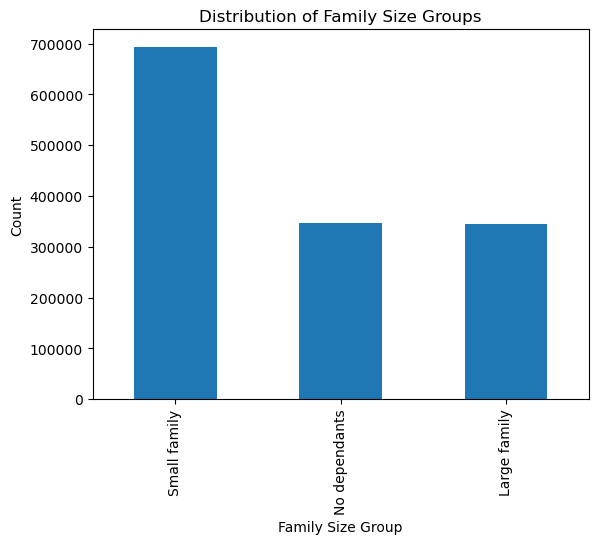

In [6]:
df['family_size_groups'] = df['n_dependants'].apply(get_dependant_category)
df['family_size_groups'].value_counts().plot(kind='bar')
plt.title('Distribution of Family Size Groups')
plt.xlabel('Family Size Group')
plt.ylabel('Count')
plt.xticks(raotation=45)
plt.tight_layout()
plt.show()

In [7]:
df.columns

Index(['order_id', 'order_number', 'order_dow', 'order_hour_of_day',
       'days_since_prior_order', 'add_to_cart_order', 'reordered',
       'product_name', 'prices', 'department', 'aisle', 'First Name',
       'Surname', 'Gender', 'state', 'Age', 'date_joined', 'n_dependants',
       'fam_status', 'income', 'region', 'division', 'family_size_groups'],
      dtype='str')

## Senior Flag

In [12]:

df['senior_flag'] = df['Age'].apply(set_senior_flag)
df.tail()

,order_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,add_to_cart_order,reordered,product_name,prices,department,...,state,Age,date_joined,n_dependants,fam_status,income,region,division,family_size_groups,senior_flag
1384701,272231,14,6,14,30.0,4,0,Fabric Softener Sheets,1.4,household,...,Iowa,74,9/14/2019,3,married,137969,Midwest,West North Central,Large family,Senior
1384702,272231,14,6,14,30.0,5,0,Dark Chocolate Mint Snacking Chocolate,2.1,snacks,...,Iowa,74,9/14/2019,3,married,137969,Midwest,West North Central,Large family,Senior
1384703,272231,14,6,14,30.0,6,0,Phish Food Frozen Yogurt,2.7,frozen,...,Iowa,74,9/14/2019,3,married,137969,Midwest,West North Central,Large family,Senior
1384704,272231,14,6,14,30.0,7,0,French Baguette Bread,15.0,bakery,...,Iowa,74,9/14/2019,3,married,137969,Midwest,West North Central,Large family,Senior
1384705,272231,14,6,14,30.0,8,1,Original Multigrain Spoonfuls Cereal,3.3,breakfast,...,Iowa,74,9/14/2019,3,married,137969,Midwest,West North Central,Large family,Senior


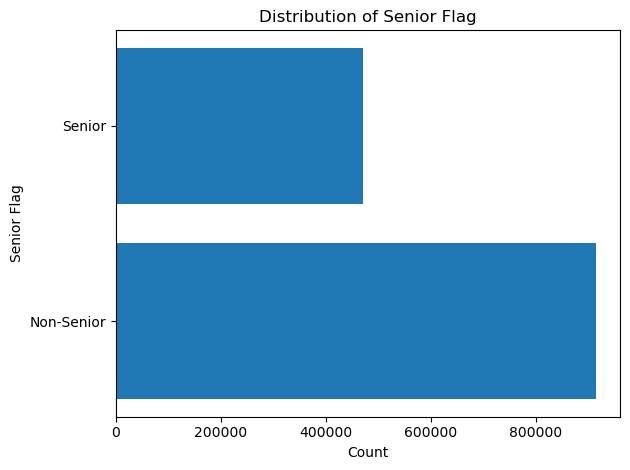

In [10]:
senior_counts = df['senior_flag'].value_counts()

plt.figure()
plt.barh(senior_counts.index, senior_counts.values)
plt.title('Distribution of Senior Flag')
plt.xlabel('Count')     
plt.ylabel('Senior Flag')
plt.tight_layout()
plt.show()

## Income Groups

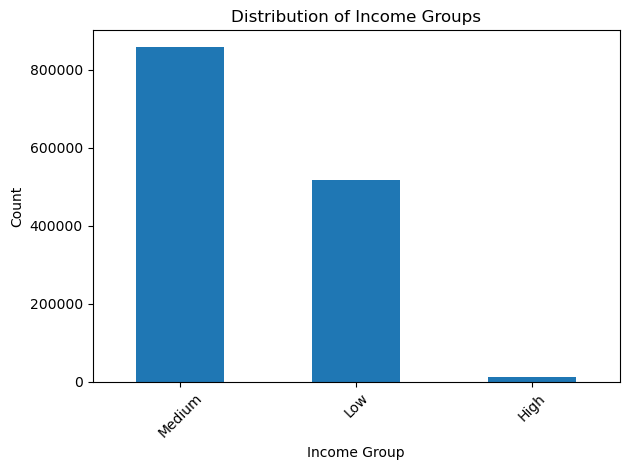

In [14]:
income_groups = df['income'].apply(income_band)
income_groups.value_counts().plot(kind='bar')
plt.title('Distribution of Income Groups')
plt.xlabel('Income Group')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Reorder Rate

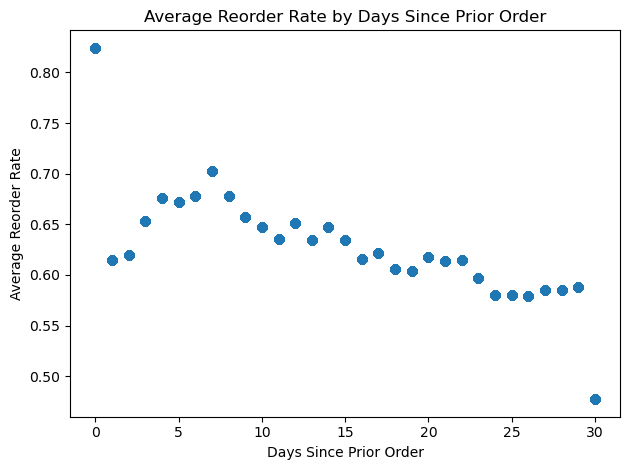

In [20]:
df['order_time_band'] = df.groupby('days_since_prior_order')['reordered'].transform('mean')
df.head(20)
type(df['order_time_band'])

plt.figure()
plt.scatter(df['days_since_prior_order'], df['order_time_band'])
plt.title('Average Reorder Rate by Days Since Prior Order')
plt.xlabel('Days Since Prior Order')
plt.ylabel('Average Reorder Rate')
plt.tight_layout()
plt.show()

## DOW Flag

In [27]:
df['IsWeekend'] = df['order_dow'].apply(lambda x: "True" if x in [0,6] else "False")
df['IsWeekday'] = df['order_dow'].isin([1,2,3,4,5])
df.head()

,order_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,add_to_cart_order,reordered,product_name,prices,department,...,n_dependants,fam_status,income,region,division,family_size_groups,senior_flag,order_time_band,IsWeekend,IsWeekday
0,1187899,11,4,8,14.0,1,1,Soda,9.0,beverages,...,3,married,40423,South,East South Central,Large family,Non-Senior,0.647644,False,True
1,1187899,11,4,8,14.0,2,1,Organic String Cheese,8.6,dairy eggs,...,3,married,40423,South,East South Central,Large family,Non-Senior,0.647644,False,True
2,1187899,11,4,8,14.0,3,1,0% Greek Strained Yogurt,12.6,dairy eggs,...,3,married,40423,South,East South Central,Large family,Non-Senior,0.647644,False,True
3,1187899,11,4,8,14.0,4,1,XL Pick-A-Size Paper Towel Rolls,1.0,household,...,3,married,40423,South,East South Central,Large family,Non-Senior,0.647644,False,True
4,1187899,11,4,8,14.0,5,1,Milk Chocolate Almonds,6.8,snacks,...,3,married,40423,South,East South Central,Large family,Non-Senior,0.647644,False,True
